# Customer Purchase Pattern Analysis Using Python

## Project Objectives

* Analyze customer purchasing behavior using transaction data.
* Clean and preprocess the dataset for accurate analysis.
* Perform exploratory data analysis to discover sales trends and customer insights.
* Identify top-performing products, customers, and countries based on revenue.
* Analyze monthly, daily, and hourly purchasing patterns.
* Implement RFM (Recency, Frequency, Monetary) Analysis to segment customers.
* Generate actionable business insights to support customer retention and marketing strategies.


##1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/online_retail_II.xlsx")

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
# Check first 5 records
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
print("Rows :", df.shape[0])

Rows : 525461


In [ ]:
print("Columns :", df.shape[1])

Columns : 8


In [ ]:
# ====================================
# Read Both Sheets
# ====================================

# Read 2009-2010 data
df1 = pd.read_excel("/content/drive/MyDrive/online_retail_II.xlsx", sheet_name="Year 2009-2010")

In [ ]:
df1.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Read 2010-2011 data
df2 = pd.read_excel("/content/drive/MyDrive/online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [ ]:
df2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df2.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
541909,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [ ]:
# Combine both datasets
df = pd.concat([df1, df2], ignore_index=True)

## 3. Data Understanding

In [ ]:
df


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
# Check first 5 records
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


## 4. Data Cleaning

In [ ]:
# Check missing values
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
# ====================================
# Dataset size before cleaning
# ====================================
print("Rows before Cleaning: ", df.shape[0])

Rows before Cleaning:  1067371


In [ ]:
# ====================================
# Remove missing values
# ====================================

# Remove rows where Customer ID or Description is missing
df=df.dropna(subset=["Customer ID", "Description"])


In [ ]:
# ====================================
# Dataset size before cleaning
# ====================================
print("Rows After Cleaning:", df.shape[0])

Rows After Cleaning: 824364


In [ ]:
# Check missing values again
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [ ]:
# ====================================
# Check Duplicate Records
# ====================================

# Count duplicate rows
duplicate_count=df.duplicated().sum()
print("Duplicate Records :",duplicate_count)

Duplicate Records : 26479


In [ ]:
# ====================================
# Remove Duplicate Records
# ====================================

# Remove duplicate rows
df= df.drop_duplicates()
print("Rows After Removing Duplicates :", df.shape[0])




Rows After Removing Duplicates : 797885


In [ ]:
# Count duplicate rows
duplicate_count=df.duplicated().sum()
print("Duplicate Records :",duplicate_count)

Duplicate Records : 0



Check for Cancelled Orders

In [ ]:
# Find cancelled orders
cancelled_orders=df["Invoice"].astype(str).str.startswith("C").sum()

print("Cancelled Orders :", cancelled_orders)

Cancelled Orders : 18390


Check Negative Quantity

A negative quantity usually means:

1.   Product Return
2.   Order cancellation

In [ ]:
# ====================================
# Check Negative Quantity
# ====================================

negative_quanity = (df["Quantity"] <0).sum()
print("Negative Quantity :", negative_quanity)


Negative Quantity : 18390


In [ ]:
#Remove Cancelled Orders
# ====================================
# Remove Cancelled Orders
# ====================================

# Keep only completed purchases
df = df[df["Quantity"] > 0]

print("Rows After Removing Cancelled Orders :", df.shape[0])

Rows After Removing Cancelled Orders : 779495


In [ ]:
#Check Zero or Negative Price
# ====================================
# Check Invalid Price
# ====================================

# Count records with zero or negative price
invalid_price = (df["Price"] <= 0).sum()

print("Invalid Price Records :", invalid_price)

Invalid Price Records : 70


In [ ]:
#Remove Invalid Price Records


# ====================================
# Check Invalid Price
# ====================================

invalid_price = (df["Price"] <= 0).sum()

print("Invalid Price Records :", invalid_price)

Invalid Price Records : 70


In [ ]:
# ====================================
# Remove Invalid Price Records
# ====================================

# Keep only records with valid price
df = df[df["Price"] > 0]

print("Rows After Removing Invalid Price :", df.shape[0])

Rows After Removing Invalid Price : 779425


## 5. Feature Engineering

In [ ]:
#Create Revenue Column ⭐


# ====================================
# Create Revenue Column
# ====================================

# Revenue = Quantity × Price
df["Revenue"] = df["Quantity"] * df["Price"]

# Check first few records
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
#Check Revenue Statistics
# ====================================
# Revenue Summary
# ====================================

df["Revenue"].describe()

,Revenue
count,779425.000000
mean,22.291823
std,227.427075
min,0.001000
25%,4.950000
50%,12.480000
75%,19.800000
max,168469.600000


In [ ]:
# ====================================
# Total Revenue
# ====================================

total_revenue = df["Revenue"].sum()

print("Total Revenue :", total_revenue)

Total Revenue : 17374804.268000003


In [ ]:
# ====================================
# Average Revenue per Transaction
# ====================================

average_revenue = df["Revenue"].mean()

print("Average Revenue :", round(average_revenue, 2))


Average Revenue : 22.29


In [ ]:
# ====================================
# Total Spending By Each Customer
# ====================================

customer_spending = df.groupby("Customer ID")["Revenue"].sum()

customer_spending.head()

,Revenue
Customer ID,
12346.0,77556.46
12347.0,4921.53
12348.0,2019.40
12349.0,4428.69
12350.0,334.40


In [ ]:
# ====================================
# Top 10 Customers By Revenue
# ====================================

top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,Revenue
Customer ID,
18102.0,580987.04
14646.0,528602.52
14156.0,313437.62
14911.0,291420.81
17450.0,244784.25
13694.0,195640.69
17511.0,172132.87
16446.0,168472.50
16684.0,147142.77


In [ ]:
# ====================================
# Number Of Orders By Each Customer
# ====================================

customer_orders = (
    df.groupby("Customer ID")["Invoice"]
      .count()
      .sort_values(ascending=False)
)

customer_orders.head(10)


,Invoice
Customer ID,
17841.0,12435
14911.0,11077
12748.0,6585
14606.0,6359
14096.0,5111
15311.0,4306
14156.0,4038
14646.0,3849
13089.0,3315


In [ ]:
# ====================================
# Convert Invoice Date
# ====================================

# Convert InvoiceDate to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Check data type
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [ ]:
# ====================================
# Create Date Features
# ====================================

# Purchase Year
df["Year"] = df["InvoiceDate"].dt.year

# Purchase Month
df["Month"] = df["InvoiceDate"].dt.month

# Purchase Day Name
df["Day"] = df["InvoiceDate"].dt.day_name()

# Purchase Hour
df["Hour"] = df["InvoiceDate"].dt.hour


In [ ]:

# Check new columns
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,Tuesday,7


In [ ]:
#Check the New Features

#Years in the data
# Check available years
df["Year"].unique()

array([2009, 2010, 2011], dtype=int32)

In [ ]:

# Check available months
df["Month"].unique()


array([12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32)

In [ ]:
# Check available days
df["Day"].unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

In [ ]:
# Check available hours
df["Hour"].unique()

array([ 7,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  8, 20,  6],
      dtype=int32)

In [ ]:
# ====================================
# Revenue By Month
# ====================================

highest_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

highest_revenue

,Revenue
Month,
11,2322665.632
10,2068754.460
9,1779704.153
12,1771135.180
6,1296417.180
3,1291060.231
5,1275188.530
8,1246275.640
7,1188699.071


## 6. Exploratory Data Analysis (EDA)

# ====================================Product Analysis

In [ ]:
# ====================================
# Top 10 Products By Revenue
# ====================================

top_products = (
    df.groupby("StockCode")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products


,Revenue
StockCode,
22423,277656.25
85123A,247203.36
23843,168469.60
85099B,167920.64
M,151777.67
POST,124648.04
84879,124351.86
47566,103283.38
23166,81416.73


In [ ]:
# ====================================
# Top 10 Highest Spending Customers
# ====================================

top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,Revenue
Customer ID,
18102.0,580987.04
14646.0,528602.52
14156.0,313437.62
14911.0,291420.81
17450.0,244784.25
13694.0,195640.69
17511.0,172132.87
16446.0,168472.50
16684.0,147142.77


In [ ]:
# ====================================
# Top 10 Customers By Number Of Orders
# ====================================

top_orders = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

top_orders


,Invoice
Customer ID,
14911.0,398
12748.0,336
17841.0,211
15311.0,208
13089.0,203
14606.0,192
14156.0,156
17850.0,155
14646.0,151


In [ ]:
# ====================================
# Top 10 Customers By Quantity Purchased
# ====================================

top_quantity = (
    df.groupby("Customer ID")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_quantity

,Quantity
Customer ID,
14646.0,367193
13902.0,220600
13694.0,188201
18102.0,181645
14156.0,164325
14911.0,147972
17511.0,117174
16684.0,104810
14298.0,100272


In [ ]:
# ====================================
# Top 10 Products By Quantity Sold
# ====================================

top_products_quantity = (
    df.groupby("StockCode")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_quantity

,Quantity
StockCode,
84077,105185
85099B,93436
85123A,91814
21212,89850
23843,80995
84879,78234
23166,77916
22197,76944
17003,70082


In [ ]:
# ====================================
# Top 10 Countries By Revenue
# ====================================

top_countries = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries

,Revenue
Country,
United Kingdom,1.438923e+07
EIRE,6.165705e+05
Netherlands,5.540381e+05
Germany,4.250197e+05
France,3.487690e+05
Australia,1.692835e+05
Spain,1.083325e+05
Switzerland,1.000619e+05
Sweden,9.151582e+04


In [ ]:
# ====================================
#  Top 10 Products by Revenue

# ====================================

df.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False).head(10)


,Revenue
StockCode,
22423,277656.25
85123A,247203.36
23843,168469.60
85099B,167920.64
M,151777.67
POST,124648.04
84879,124351.86
47566,103283.38
23166,81416.73


====================================
Time Analysis
====================================



In [ ]:
# ====================================
# Revenue By Month
# ====================================

month_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

month_revenue

,Revenue
Month,
11,2322665.632
10,2068754.460
9,1779704.153
12,1771135.180
6,1296417.180
3,1291060.231
5,1275188.530
8,1246275.640
7,1188699.071


In [ ]:
# ====================================
# Orders By Month
# ====================================

month_orders = (
    df.groupby("Month")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
)

month_orders

,Invoice
Month,
11,5244
10,4062
12,3690
9,3444
5,2932
6,2890
3,2845
7,2712
8,2573


In [ ]:
# ====================================
# Revenue By Day
# ====================================

day_revenue = (
    df.groupby("Day")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

day_revenue

,Revenue
Day,
Thursday,3745783.432
Tuesday,3322830.142
Wednesday,3021043.853
Monday,2778201.566
Friday,2728473.173
Sunday,1768669.052
Saturday,9803.050


In [ ]:
# ====================================
# Orders By Hour
# ====================================

hour_orders = (
    df.groupby("Hour")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
)

hour_orders

,Invoice
Hour,
12,6170
13,5418
11,4609
14,4559
10,4364
15,3992
9,2548
16,2306
17,1158


In [ ]:
#====================================
#Revenue by Hour
# ===================================
df.groupby("Hour")["Revenue"].sum().sort_values(ascending=False)

,Revenue
Hour,
12,2690583.501
13,2347078.714
10,2320711.443
11,2235870.393
14,1962016.161
15,1839607.762
9,1484450.541
16,1055274.691
8,524612.550


===================================**=Country Analysis**

In [ ]:
# ====================================
# Top 10 Countries By Revenue
# ====================================

country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_revenue

,Revenue
Country,
United Kingdom,1.438923e+07
EIRE,6.165705e+05
Netherlands,5.540381e+05
Germany,4.250197e+05
France,3.487690e+05
Australia,1.692835e+05
Spain,1.083325e+05
Switzerland,1.000619e+05
Sweden,9.151582e+04


In [ ]:
country_customers = (
    df.groupby("Country")["Customer ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

country_customers

,Customer ID
Country,
United Kingdom,5350
Germany,107
France,95
Spain,41
Belgium,29
Portugal,24
Switzerland,22
Netherlands,22
Sweden,19


In [ ]:
country_orders = (
    df.groupby("Country")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

country_orders

,Invoice
Country,
United Kingdom,33541
Germany,789
France,614
EIRE,567
Netherlands,228
Spain,154
Belgium,149
Sweden,104
Australia,95


 ====================================**RFM Analysis**

In [ ]:
# ====================================
# Latest Purchase Date
# ====================================

latest_date = df["InvoiceDate"].max()

print(latest_date)

2011-12-09 12:50:00


In [ ]:
# ====================================
# Create RFM Table
# ====================================

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": "max",
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.head()

,InvoiceDate,Invoice,Revenue
Customer ID,,,
12346.0,2011-01-18 10:01:00,12,77556.46
12347.0,2011-12-07 15:52:00,8,4921.53
12348.0,2011-09-25 13:13:00,5,2019.40
12349.0,2011-11-21 09:51:00,4,4428.69
12350.0,2011-02-02 16:01:00,1,334.40


In [ ]:
# ====================================
# Calculate Recency
# ====================================

rfm["Recency"] = (
    latest_date - rfm["InvoiceDate"]
).dt.days

rfm.head()

,InvoiceDate,Invoice,Revenue,Recency
Customer ID,,,,
12346.0,2011-01-18 10:01:00,12,77556.46,325
12347.0,2011-12-07 15:52:00,8,4921.53,1
12348.0,2011-09-25 13:13:00,5,2019.40,74
12349.0,2011-11-21 09:51:00,4,4428.69,18
12350.0,2011-02-02 16:01:00,1,334.40,309


In [ ]:
# ====================================
# Rename Columns
# ====================================

rfm.rename(columns={
    "Invoice": "Frequency",
    "Revenue": "Monetary"
}, inplace=True)

rfm.head()

,InvoiceDate,Frequency,Monetary,Recency
Customer ID,,,,
12346.0,2011-01-18 10:01:00,12,77556.46,325
12347.0,2011-12-07 15:52:00,8,4921.53,1
12348.0,2011-09-25 13:13:00,5,2019.40,74
12349.0,2011-11-21 09:51:00,4,4428.69,18
12350.0,2011-02-02 16:01:00,1,334.40,309


In [ ]:
# ====================================
# Remove InvoiceDate
# ====================================

rfm.drop(columns="InvoiceDate", inplace=True)

rfm.head()

,Frequency,Monetary,Recency
Customer ID,,,
12346.0,12,77556.46,325
12347.0,8,4921.53,1
12348.0,5,2019.40,74
12349.0,4,4428.69,18
12350.0,1,334.40,309


In [ ]:
# ====================================
# Recency Score
# ====================================

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5,4,3,2,1]
)

rfm.head()

,Frequency,Monetary,Recency,R_Score
Customer ID,,,,
12346.0,12,77556.46,325,2
12347.0,8,4921.53,1,5
12348.0,5,2019.40,74,3
12349.0,4,4428.69,18,5
12350.0,1,334.40,309,2


In [ ]:
# ====================================
# Frequency Score
# ====================================

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

rfm.head()

,Frequency,Monetary,Recency,R_Score,F_Score
Customer ID,,,,,
12346.0,12,77556.46,325,2,5
12347.0,8,4921.53,1,5,4
12348.0,5,2019.40,74,3,4
12349.0,4,4428.69,18,5,3
12350.0,1,334.40,309,2,1


In [ ]:
# ====================================
# Monetary Score
# ====================================

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

rfm.head()

,Frequency,Monetary,Recency,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,12,77556.46,325,2,5,5
12347.0,8,4921.53,1,5,4,5
12348.0,5,2019.40,74,3,4,4
12349.0,4,4428.69,18,5,3,5
12350.0,1,334.40,309,2,1,2


In [ ]:
# ====================================
# Convert Scores to Integer
# ====================================

rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm.head()

,Frequency,Monetary,Recency,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,12,77556.46,325,2,5,5
12347.0,8,4921.53,1,5,4,5
12348.0,5,2019.40,74,3,4,4
12349.0,4,4428.69,18,5,3,5
12350.0,1,334.40,309,2,1,2


In [ ]:
# ====================================
# Total RFM Score
# ====================================

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,12,77556.46,325,2,5,5,12
12347.0,8,4921.53,1,5,4,5,14
12348.0,5,2019.40,74,3,4,4,11
12349.0,4,4428.69,18,5,3,5,13
12350.0,1,334.40,309,2,1,2,5


In [ ]:
# ====================================
# Customer Segmentation
# ====================================

def customer_segment(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 7:
        return "Potential Loyalists"

    elif score >= 4:
        return "At Risk"

    else:
        return "Lost Customers"


rfm["Customer_Segment"] = rfm["RFM_Score"].apply(customer_segment)

rfm.head()

,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
Customer ID,,,,,,,,
12346.0,12,77556.46,325,2,5,5,12,Loyal Customers
12347.0,8,4921.53,1,5,4,5,14,Champions
12348.0,5,2019.40,74,3,4,4,11,Loyal Customers
12349.0,4,4428.69,18,5,3,5,13,Champions
12350.0,1,334.40,309,2,1,2,5,At Risk


In [ ]:
# ====================================
# Customer Segment Count
# ====================================

rfm["Customer_Segment"].value_counts()

,count
Customer_Segment,
At Risk,1456
Potential Loyalists,1453
Loyal Customers,1357
Champions,1295
Lost Customers,317


In [ ]:
# ====================================
# Save RFM Table
# ====================================
rfm.to_csv("Customer_RFM_Analysis.csv")

# ====================================**Charts**

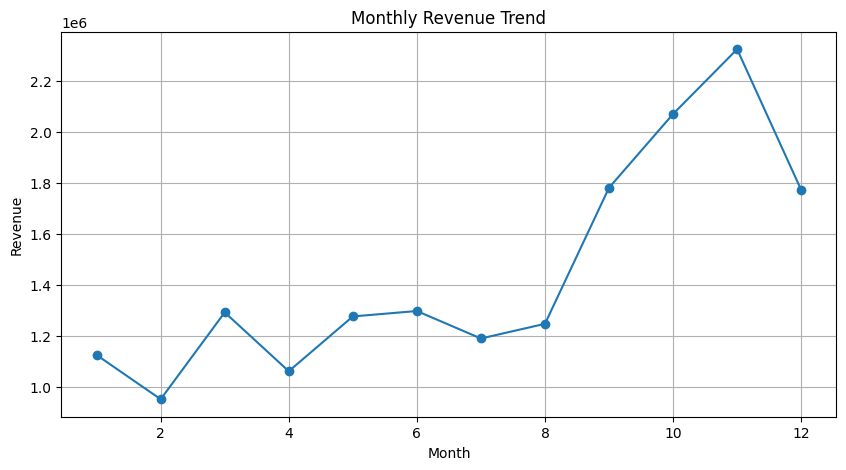

In [ ]:
# ====================================
# Monthly Revenue Trend
# ====================================

monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

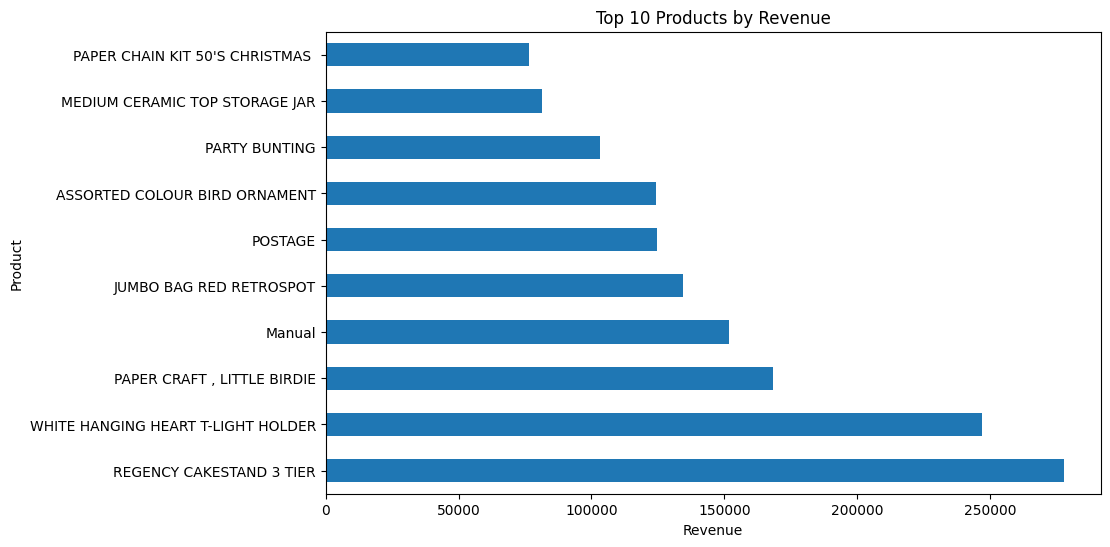

In [ ]:
# ====================================
# Top 10 Products by Revenue
# ====================================

top_products = df.groupby("Description")["Revenue"]\
                 .sum()\
                 .sort_values(ascending=False)\
                 .head(10)

plt.figure(figsize=(10,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

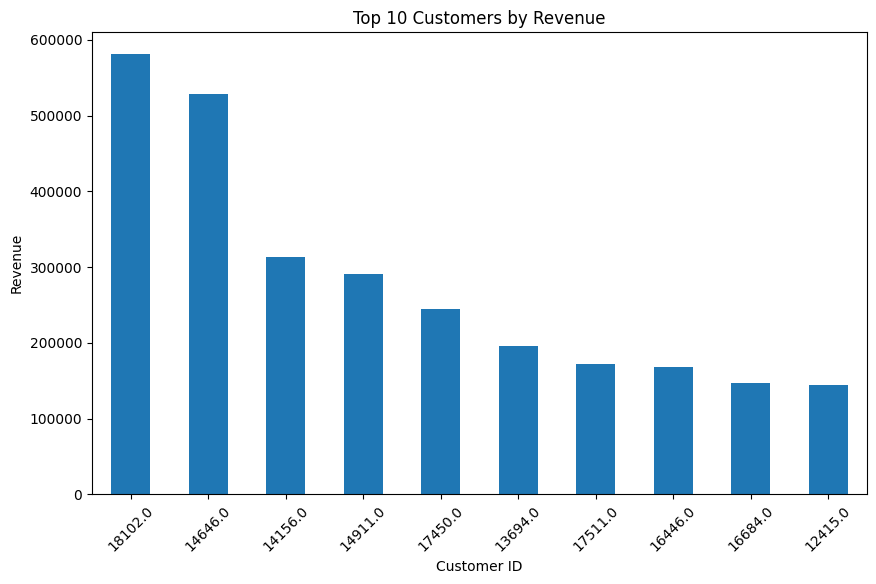

In [ ]:
# ====================================
# Top 10 Customers by Revenue
# ====================================

top_customers = df.groupby("Customer ID")["Revenue"]\
                  .sum()\
                  .sort_values(ascending=False)\
                  .head(10)

plt.figure(figsize=(10,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

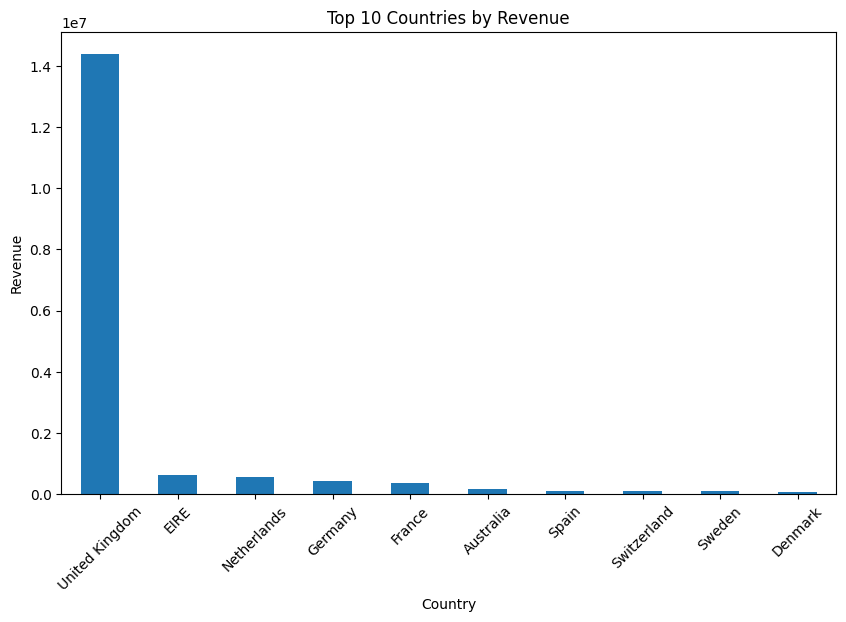

In [ ]:
# ====================================
# Revenue by Country
# ====================================

country_revenue = df.groupby("Country")["Revenue"]\
                    .sum()\
                    .sort_values(ascending=False)\
                    .head(10)

plt.figure(figsize=(10,6))

country_revenue.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

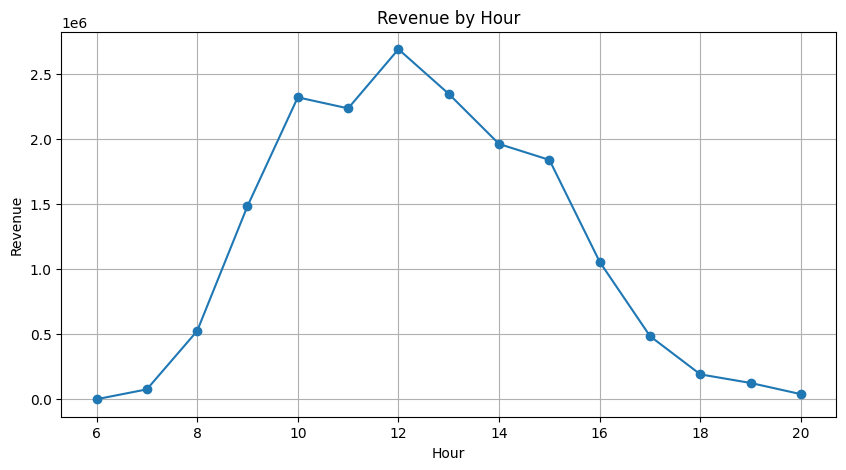

In [ ]:
# ====================================
# Hourly Revenue
# ====================================

hourly_revenue = df.groupby("Hour")["Revenue"].sum()

plt.figure(figsize=(10,5))

plt.plot(hourly_revenue.index,
         hourly_revenue.values,
         marker="o")

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

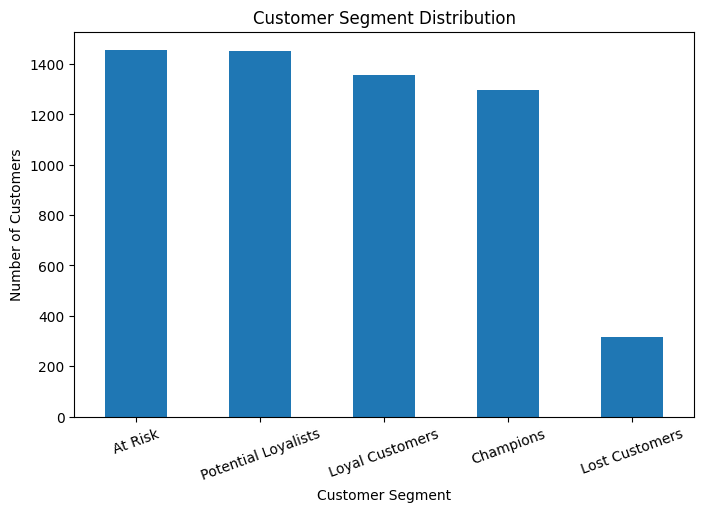

In [ ]:
# ====================================
# Customer Segment Distribution
# ====================================

segment_count = rfm["Customer_Segment"].value_counts()

plt.figure(figsize=(8,5))

segment_count.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

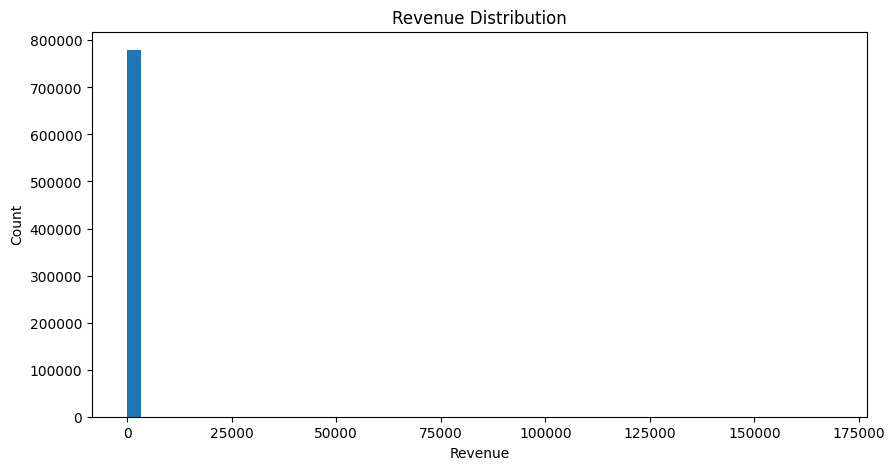

In [ ]:
# ====================================
# Revenue Distribution
# ====================================

plt.figure(figsize=(10,5))

plt.hist(df["Revenue"], bins=50)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")

plt.show()

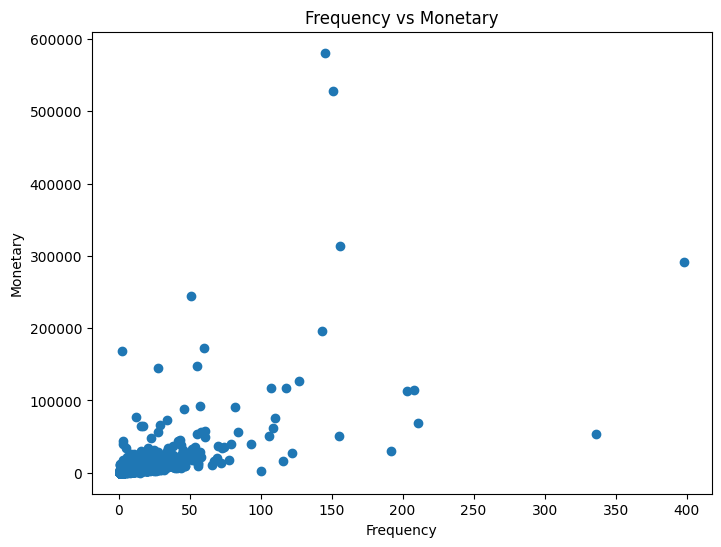

In [ ]:
# ====================================
# Frequency vs Monetary
# ====================================

plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"]
)

plt.title("Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

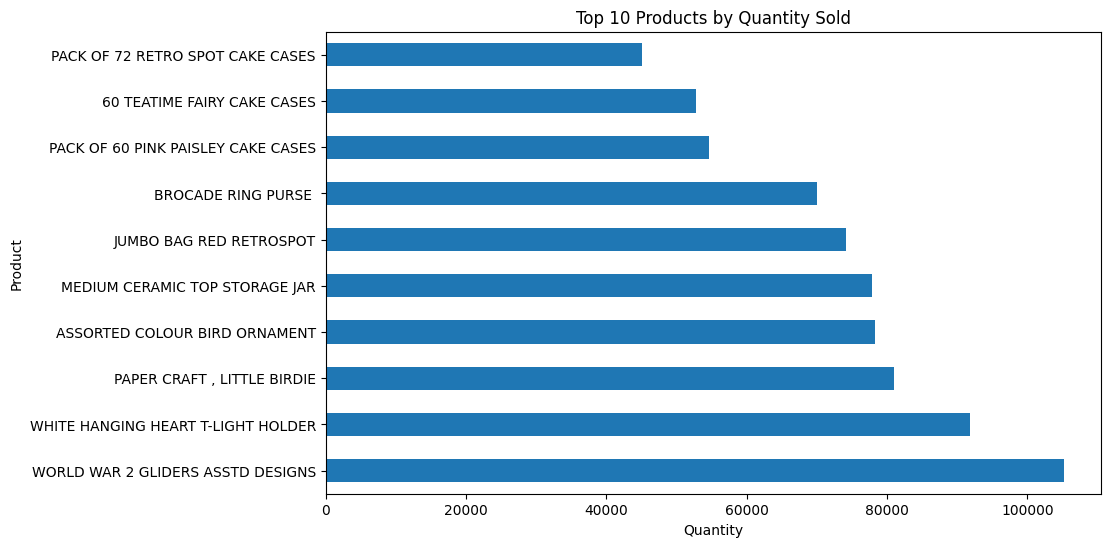

In [ ]:
# ====================================
# Top 10 Products by Quantity
# ====================================

top_quantity = df.groupby("Description")["Quantity"]\
                 .sum()\
                 .sort_values(ascending=False)\
                 .head(10)

plt.figure(figsize=(10,6))

top_quantity.plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product")

plt.show()

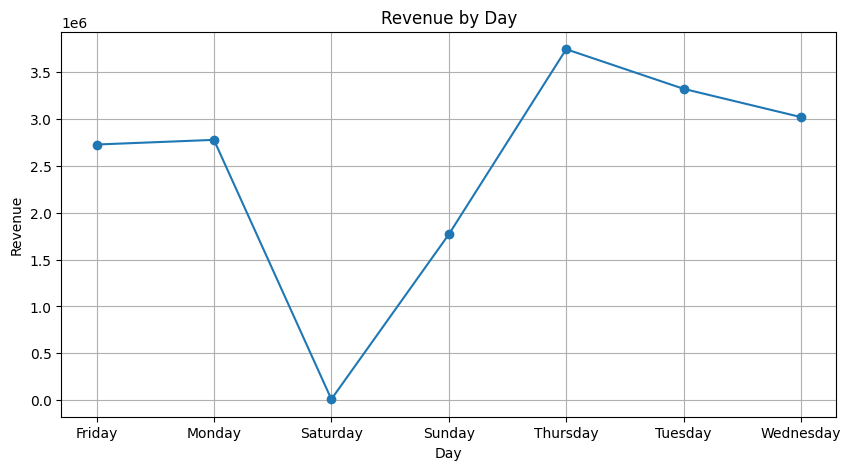

In [ ]:
# ====================================
# Revenue by Day
# ====================================

daily_revenue = df.groupby("Day")["Revenue"].sum()

plt.figure(figsize=(10,5))

plt.plot(
    daily_revenue.index,
    daily_revenue.values,
    marker="o"
)

plt.title("Revenue by Day")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

# ====================================**Conclusion**

This project analyzed customer purchase behavior using an online retail dataset. After cleaning and preparing the data, exploratory data analysis was performed to understand customer spending patterns, product performance, country-wise sales, and time-based trends. RFM (Recency, Frequency, Monetary) analysis was used to segment customers into Champions, Loyal Customers, Potential Loyalists, At Risk, and Lost Customers. The findings can help businesses improve customer retention, optimize marketing campaigns, and make data-driven business decisions.